**🚀 STEP 1: Load Dataset & Basic Inspection**

In [7]:
# Step 1: Import required libraries
import pandas as pd

# Step 2: Load dataset
# Replace with your actual file path
df = pd.read_csv("Beijing Air Quality from 2010 to 2017.csv")

# Step 3: Display first 5 rows
print("First 5 rows of dataset:")
print(df.head())

# Step 4: Check dataset info
print("\n\nDataset Info:")
print(df.info())

# Step 5: Check column names
print("\n\nColumns in dataset:")
print(df.columns)

# Step 6: Check missing values
print("\n\nMissing values in each column:")
print(df.isnull().sum())

First 5 rows of dataset:
      City Country                  Date  Season  \
0  Beijing   China  3/1/2013 12:00:00 AM  Winter   
1  Beijing   China   3/1/2013 1:00:00 AM  Winter   
2  Beijing   China   3/1/2013 2:00:00 AM  Winter   
3  Beijing   China   3/1/2013 3:00:00 AM  Winter   
4  Beijing   China   3/1/2013 4:00:00 AM  Winter   

   PM2.5 concentration (ug/m^3)  PM_Station 3  Dew Point (Fahrenheit)  \
0                           9.0           NaN                   -2.20   
1                          11.0           NaN                   -2.74   
2                           8.0           NaN                   -3.46   
3                           8.0           NaN                   -5.62   
4                           8.0           NaN                   -7.06   

   Temperature (Fahrenheit)  PM2.5  PM10 concentration (ug/m^3)  ...  \
0                      32.0    9.0                          9.0  ...   
1                      32.0   11.0                         11.0  ...   
2      

**🚀 STEP 2: Data Preprocessing (Cleaning + Preparation)**

In [8]:
# Step 2: Data Preprocessing (Fixed)

# 1. Drop unnecessary columns
columns_to_drop = ['No', 'station']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# 2. Handle missing values
df = df.fillna(df.mean(numeric_only=True))

# 3. Create datetime column
if all(col in df.columns for col in ['year', 'month', 'day', 'hour']):
    df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
    df = df.drop(columns=['year', 'month', 'day', 'hour'])

# 4. Handle ONLY wind direction (wd column)
if 'wd' in df.columns:
    df['wd'] = df['wd'].astype('category').cat.codes

# 5. Drop datetime (not needed for basic model)
if 'datetime' in df.columns:
    df = df.drop(columns=['datetime'])

# 6. Final check
print("After preprocessing:")
print(df.head())

print("\nMissing values after cleaning:")
print(df.isnull().sum())

After preprocessing:
      City Country                  Date  Season  \
0  Beijing   China  3/1/2013 12:00:00 AM  Winter   
1  Beijing   China   3/1/2013 1:00:00 AM  Winter   
2  Beijing   China   3/1/2013 2:00:00 AM  Winter   
3  Beijing   China   3/1/2013 3:00:00 AM  Winter   
4  Beijing   China   3/1/2013 4:00:00 AM  Winter   

   PM2.5 concentration (ug/m^3)  PM_Station 3  Dew Point (Fahrenheit)  \
0                           9.0     88.643737                   -2.20   
1                          11.0     88.643737                   -2.74   
2                           8.0     88.643737                   -3.46   
3                           8.0     88.643737                   -5.62   
4                           8.0     88.643737                   -7.06   

   Temperature (Fahrenheit)  PM2.5  PM10 concentration (ug/m^3)  ...  \
0                      32.0    9.0                          9.0  ...   
1                      32.0   11.0                         11.0  ...   
2          

**🚀 STEP 3: Feature Cleaning + Selection + Train/Test Split**

In [10]:
# Step 3: Feature Cleaning + Selection

# 1. Remove unnecessary columns
cols_to_drop = ['City', 'Country']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# 2. Handle duplicate PM columns
# Keep only one target column
if 'PM2.5 concentration (ug/m^3)' in df.columns:
    df = df.rename(columns={'PM2.5 concentration (ug/m^3)': 'PM2.5_target'})

if 'PM2.5' in df.columns:
    df = df.drop(columns=['PM2.5'])  # remove duplicate

# 3. Convert Date column → extract useful features
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df['hour'] = df['Date'].dt.hour
    df['day'] = df['Date'].dt.day
    df['month'] = df['Date'].dt.month
    df = df.drop(columns=['Date'])

# 4. Convert Season → numeric
if 'Season' in df.columns:
    df['Season'] = df['Season'].astype('category').cat.codes

# 5. Handle Wind Direction
if 'Wind Direction' in df.columns:
    df['Wind Direction'] = df['Wind Direction'].astype('category').cat.codes
    df['Wind Direction'] = df['Wind Direction'].fillna(df['Wind Direction'].mean())

# 6. Final check
print("Cleaned dataset:")
print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

Cleaned dataset:
   Season  PM2.5_target  PM_Station 3  Dew Point (Fahrenheit)  \
0       3           9.0     88.643737                   -2.20   
1       3          11.0     88.643737                   -2.74   
2       3           8.0     88.643737                   -3.46   
3       3           8.0     88.643737                   -5.62   
4       3           8.0     88.643737                   -7.06   

   Temperature (Fahrenheit)  PM10 concentration (ug/m^3)  \
0                      32.0                          9.0   
1                      32.0                         11.0   
2                      32.0                          8.0   
3                      32.0                          8.0   
4                      32.0                          8.0   

   SO2 concentration (ug/m^3)  NO2 concentration (ug/m^3)  \
0                    6.000000                   17.000000   
1                    7.000000                   14.000000   
2                   15.830835                   

🔥 Now Split Data for ML

In [11]:
# Step 3: Feature Cleaning + Selection + Train/Test Split

from sklearn.model_selection import train_test_split
import joblib

# Target variable
y = df['PM2.5_target']

# Features (everything except target)
X = df.drop(columns=['PM2.5_target'])

# ✅ SAVE FEATURE ORDER (VERY IMPORTANT FOR DEPLOYMENT)
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, "features.pkl")

print("Feature columns saved successfully!")

# Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

Feature columns saved successfully!

Train shape: (378681, 23)
Test shape: (94671, 23)


In [12]:
df = df.drop(columns=['Temperature (Fahrenheit)', 'Dew Point (Fahrenheit)'])

“The dataset was cleaned by removing redundant features, handling missing values, encoding categorical variables, and extracting temporal features. The final dataset contained only numerical attributes suitable for regression modeling.”

**🚀 STEP 4: Train ML Models**

In [13]:
# Step 4: Model Training

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# 1. Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
lr_predictions = lr_model.predict(X_test)

print("Linear Regression model trained successfully!")

# 2. Random Forest Model
rf_model = RandomForestRegressor(n_estimators=50, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
rf_predictions = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Linear Regression model trained successfully!
Random Forest model trained successfully!


**🚀 STEP 5: Model Evaluation**

In [15]:
# Step 5: Model Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# --- Linear Regression Evaluation ---
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("🔹 Linear Regression Performance:")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)


# --- Random Forest Evaluation ---
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("\n🔹 Random Forest Performance:")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

🔹 Linear Regression Performance:
MAE: 19.17007299274946
RMSE: 30.49995743740564
R2 Score: 0.85784128640201

🔹 Random Forest Performance:
MAE: 9.765624912961108
RMSE: 17.498299451963458
R2 Score: 0.9532085280669593


✔ MAE:

Lower = better

Average error in prediction

✔ RMSE:

Penalizes large errors

Lower = better

✔ R² Score:
Closer to 1 = best model

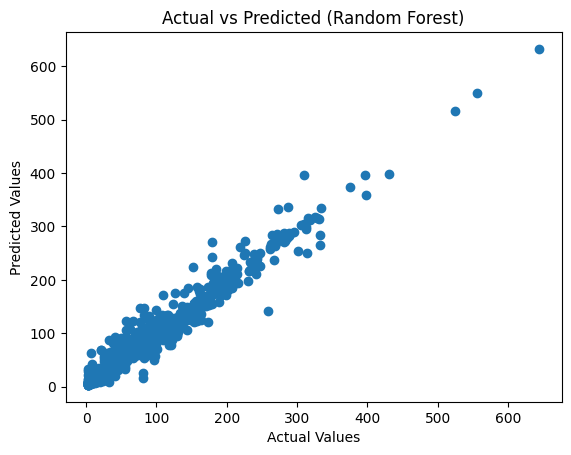

In [16]:
import matplotlib.pyplot as plt

# Plot Actual vs Predicted (Random Forest)
plt.figure()
plt.scatter(y_test[:1000], rf_predictions[:1000])
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

In [17]:
import joblib

# Save Random Forest model
joblib.dump(rf_model, "air_quality_model.pkl")

print("Model saved successfully!")

Model saved successfully!
